In [40]:
import pandas as pd

In [41]:
import mysql.connector

In [42]:
connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="MyNewSecurePass@2026",
    database="e_master_card"
)

print("Connected successfully!")

Connected successfully!


In [43]:
df_cust = pd.read_sql("SELECT * FROM customers", connection)
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [44]:
df_trans = pd.read_sql("SELECT * FROM transactions", connection)
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [45]:
df_crd = pd.read_sql("SELECT * FROM credit_profiles", connection)
df_crd.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [46]:
df_cust.describe()


,cust_id,age,annual_income
count,1000.000000,1000.000000,950.000000
mean,500.500000,36.405000,139410.314737
std,288.819436,15.666155,112416.802007
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,47627.500000
50%,500.500000,32.000000,112218.500000
75%,750.250000,46.000000,193137.500000
max,1000.000000,135.000000,449346.000000


In [47]:
# treat null values 1st then outliers
df_cust.isnull().sum()

cust_id            0
name               0
gender             0
age                0
location           0
occupation         0
annual_income     50
marital_status     0
dtype: int64

In [48]:
df_cust[df_cust.annual_income.isna()]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,NaN,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,NaN,Single
97,98,Sia Batra,Male,47,Suburb,Business Owner,NaN,Married
102,103,Pooja Ganguly,Male,32,City,Data Scientist,NaN,Married
155,156,Krishna Trivedi,Male,24,City,Fullstack Developer,NaN,Married
170,171,Advait Kulkarni,Male,52,City,Business Owner,NaN,Single
186,187,Aanya Pande,Male,53,City,Consultant,NaN,Single
192,193,Mira Naidu,Male,37,Suburb,Data Scientist,NaN,Married
227,228,Mihika Batra,Male,48,City,Business Owner,NaN,Married
232,233,Aaditya Rathore,Male,26,City,Freelancer,NaN,Married


In [49]:
df_cust.annual_income.median()

np.float64(112218.5)

In [50]:
occupation_wise_median = df_cust.groupby("occupation")["annual_income"].median()
occupation_wise_median

occupation
Accountant              65265.0
Artist                  45794.0
Business Owner         261191.5
Consultant              58017.0
Data Scientist         135759.0
Freelancer              46759.0
Fullstack Developer     76774.0
Name: annual_income, dtype: float64

In [51]:
def get_meadin_value(row):
    if pd.isnull(row["annual_income"]):
        return occupation_wise_median[row["occupation"]]
    else:
        return row["annual_income"]

In [52]:
df_cust["annual_income"] = df_cust.apply(
    get_meadin_value,
    axis = 1
)

In [53]:
df_cust.isnull().sum()

cust_id           0
name              0
gender            0
age               0
location          0
occupation        0
annual_income     0
marital_status    0
dtype: int64

In [54]:
df_cust.iloc[[14,22]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
22,23,Swara Pawar,Male,19,City,Freelancer,36863.0,Married


In [55]:
import matplotlib.pyplot as plt

print("Matplotlib working!")

Matplotlib working!


In [56]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

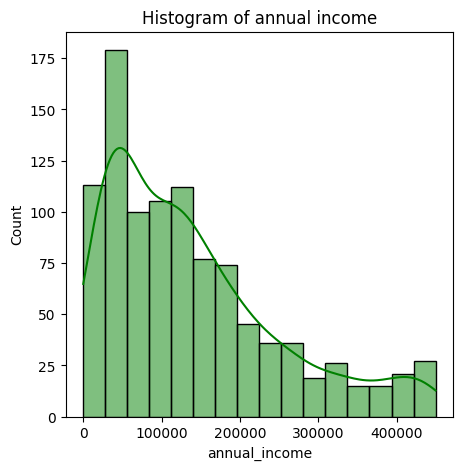

In [57]:
plt.figure(figsize=(5,5))
sns.histplot(df_cust['annual_income'], kde = True, color = 'green', label = 'Data')
plt.title("Histogram of annual income")
plt.show()

HANDELING OUTLIERS

In [58]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


In [59]:
df_cust[df_cust.annual_income < 100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,50.0,Married
262,263,Veer Rathod,Male,53,Suburb,Business Owner,50.0,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,50.0,Married
333,334,Samaira D'Souza,Female,29,City,Data Scientist,50.0,Married
340,341,Ridhi Rastogi,Female,33,Rural,Fullstack Developer,50.0,Married
543,544,Gauri Gupta,Male,54,City,Consultant,2.0,Married
592,593,Vivaan Pande,Female,32,City,Business Owner,50.0,Married
633,634,Aradhya Pandey,Male,26,City,Data Scientist,2.0,Married
686,687,Gauri Nanda,Male,40,City,Business Owner,2.0,Married
696,697,Avani Lalwani,Male,47,City,Consultant,20.0,Married


In [60]:
def changing_values_lower_than_100 (row):
    if row["annual_income"] < 100:
        return occupation_wise_median [row["occupation"]]
    else:
        return row["annual_income"]

In [61]:

df_cust["annual_income"] = df_cust.apply(
    changing_values_lower_than_100,
    axis = 1
)

In [62]:
df_cust[df_cust.annual_income < 100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [63]:
# for index, row in df_cust.iterrows():
#     if row["annual_income"] < 100:
#         df_cust.at[index, "annual_income"] == occupation_wise_median[row["occupation"]]

DATA VISUALIZATION

In [64]:
occupation_wise_average = df_cust.groupby("occupation")["annual_income"].mean()
occupation_wise_average

occupation
Accountant              64123.562500
Artist                  45309.236842
Business Owner         268447.368512
Consultant              60703.154639
Data Scientist         137021.266304
Freelancer              76327.508772
Fullstack Developer     78727.972973
Name: annual_income, dtype: float64

In [65]:
occupation_wise_average.values

array([ 64123.5625    ,  45309.23684211, 268447.36851211,  60703.15463918,
       137021.26630435,  76327.50877193,  78727.97297297])

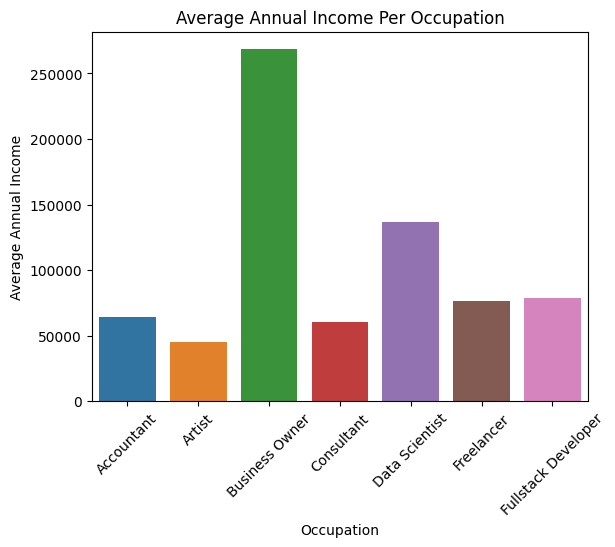

In [66]:
sns.barplot(x = occupation_wise_average.index, y = occupation_wise_average.values, palette = "tab10")
plt.xticks(rotation = 45)
plt.title('Average Annual Income Per Occupation')
plt.xlabel('Occupation')
plt.ylabel("Average Annual Income")
plt.show()

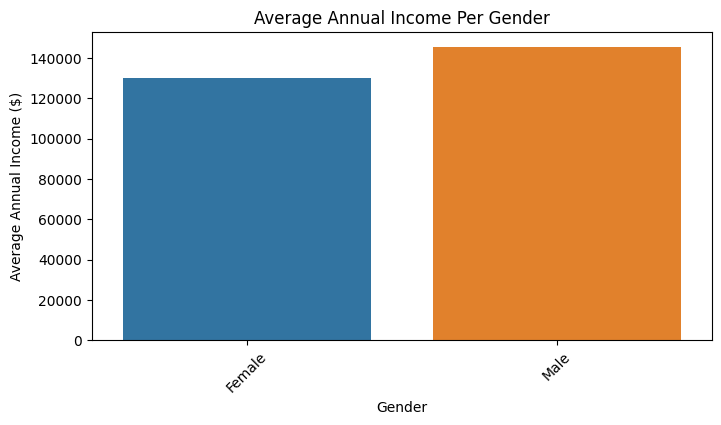

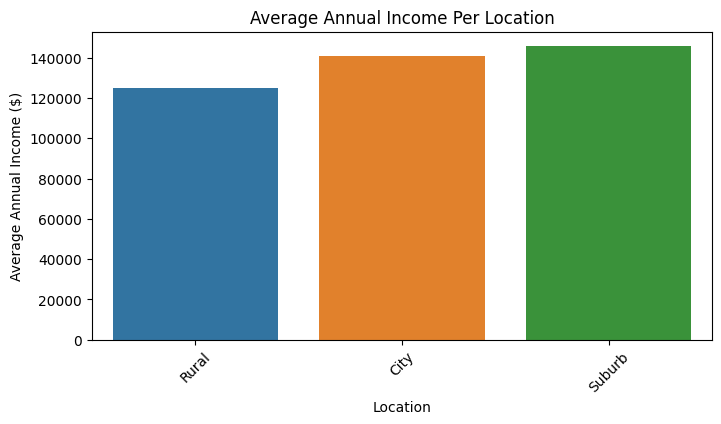

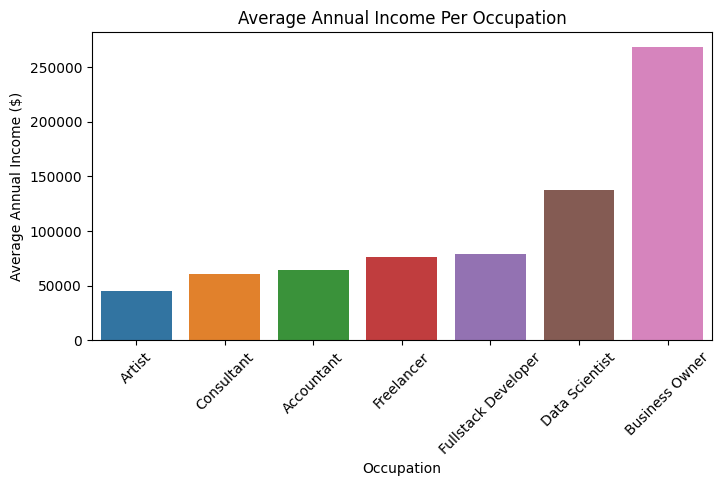

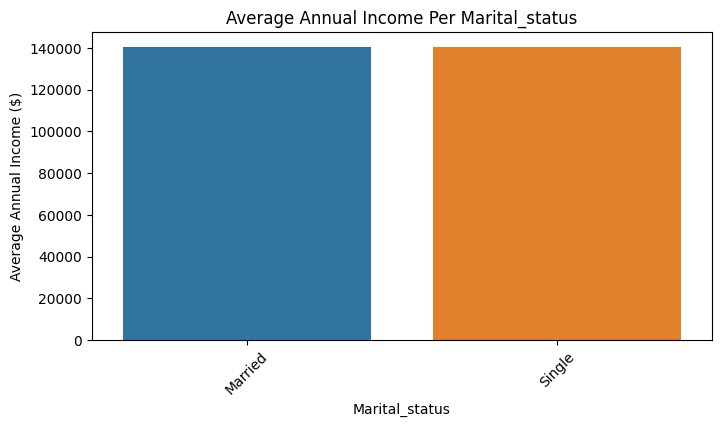

In [85]:
categorical_columns = ['gender','location','occupation','marital_status']

for col in categorical_columns:
     plt.figure(figsize=(8, 4))
     occupation_wise_average = df_cust.groupby(col)['annual_income'].mean().sort_values()
     sns.barplot(x=occupation_wise_average.index, y=occupation_wise_average.values, palette='tab10')
     plt.xticks(rotation=45)
     plt.title(f'Average Annual Income Per {col.capitalize()}')
     plt.xlabel(col.capitalize())
     plt.ylabel('Average Annual Income ($)')
     plt.show()